### 1. Detect Ripples and Insert into the Database. [This notebook populates the RippleTimes table.]
##### The RippleTimes table is under shijiegu github/spyglass/shijiegu/Analysis_SGU.py. It is not in the Franklab spyglass.
##### Only run this after another shijiegu's customized TrialChoice table is populated.

May 7, 2024
Shijie Gu

In [1]:
%reload_ext autoreload
%autoreload 2

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import spikeinterface as si
import pynwb
import xarray as xr
import os

from spyglass.common import (IntervalPositionInfo, IntervalPositionInfoSelection, IntervalList, 
                             ElectrodeGroup, LFP, BrainRegion, LFPBand, Electrode)
from ripple_detection.core import (gaussian_smooth,
                                   get_envelope,
                                   get_multiunit_population_firing_rate,
                                   threshold_by_zscore,
                                   segment_boolean_series,
                                   exclude_close_events,
                                   exclude_movement,
                                   extend_threshold_to_mean,
                                    merge_overlapping_ranges)
from ripple_detection.detectors import multiunit_HSE_detector,_get_event_stats
from spyglass.utils.nwb_helper_fn import get_nwb_copy_filename

from spyglass.spikesorting.v0 import (SortGroup, 
                                    SortInterval,
                                    SpikeSortingPreprocessingParameters,
                                    SpikeSortingRecording, 
                                    SpikeSorterParameters,
                                    SpikeSortingRecordingSelection,
                                    ArtifactDetectionParameters, ArtifactDetectionSelection,
                                    ArtifactRemovedIntervalList, ArtifactDetection,
                                      SpikeSortingSelection, SpikeSorting,)
from spyglass.shijiegu.load import load_spike
from spyglass.shijiegu.Analysis_SGU import DecodeResultsLinear

[2026-03-15 13:58:05,388][INFO]: DataJoint 0.14.4 connected to shijiegu-alt@lmf-db.cin.ucsf.edu:3306


In [9]:
from spyglass.shijiegu.Analysis_SGU import TrialChoice,RippleTimes,EpochPos
from spyglass.shijiegu.helpers import interval_union,interpolate_to_new_time
from spyglass.shijiegu.load import load_LFP,load_position
from spyglass.shijiegu.ripple_detection import (loadRippleLFP,ExtendInterSection,InterSection,
                                                plot_ripple,threshold_by_zscore_Gu,
                                                Kay_ripple_detector,Karlsson_ripple_detector,Gu_ripple_detector,multiunit_HSE_detector,
                                                removeDataBeforeTrial1,removeArtifactTime,
                                                loadRippleLFP_OneChannelPerElectrode,ripple_detection_master)
from spyglass.shijiegu.Analysis_SGU import TetrodeNumber,ChannelNumber,MUA
from spyglass.common.common_position import IntervalLinearizedPosition
from spyglass.common.common_task import TaskEpoch


In [10]:
nwb_file_name = "julio20230731.nwb"#"molly20220420.nwb" #'klein20231112.nwb'

In [11]:
nwb_copy_file_name=get_nwb_copy_filename(nwb_file_name)

In [12]:
epochs = (EpochPos() & {'nwb_file_name': nwb_copy_file_name}).fetch('epoch')

EpochPos() & {'nwb_file_name': nwb_copy_file_name}

nwb_file_name name of the NWB file,epoch the session epoch for this task and apparatus(1 based),epoch_name TaskEpoch or IntervalList,position_interval IntervalPositionInfo
julio20230731_.nwb,1,01_Seq2Sleep1,pos 0 valid times
julio20230731_.nwb,2,02_Seq2Session1,pos 1 valid times
julio20230731_.nwb,3,03_Seq2Sleep2,pos 2 valid times
julio20230731_.nwb,4,04_Seq2Session2,pos 3 valid times
julio20230731_.nwb,5,05_Seq2Sleep3,pos 4 valid times
julio20230731_.nwb,6,06_Seq2Session3,pos 5 valid times
julio20230731_.nwb,7,07_Seq2Sleep4,pos 6 valid times
julio20230731_.nwb,8,08_Seq2Session4,pos 7 valid times
julio20230731_.nwb,9,09_Seq2Sleep5,pos 8 valid times
julio20230731_.nwb,10,10_Seq2Session5,pos 9 valid times


### Very important, input channels with strong ripples

In [7]:
ripple_channels = [(4,3),
                   (7,1),(8,1),(9,1),(12,1),(13,1),(16,1),(21,1),(23,1),(28,1),(29,2),
                   (30,1),(31,1),(32,1),
                   (50,1),(52,1),(56,3),(57,4),(62,1)
                  ]

#### run the rest of the section

In [31]:
ripple_electrode_id = []
for tetrode_channel in ripple_channels:
    (tetrode, channel_num) = tetrode_channel
    query_sortgroup = SortGroup() & {'nwb_file_name' : nwb_copy_file_name,
                                     "sort_group_id" : tetrode-1}
    query_electrode = (Electrode() & {'nwb_file_name' : nwb_copy_file_name,
                                      'electrode_group_name' : tetrode-1,
                                      'probe_electrode':channel_num-1})
    if len(query_sortgroup) > 0:
        ripple_electrode_id.append(query_electrode.fetch1("electrode_id"))
    else:
        print(f"Cannot find tetrode {tetrode} channel {channel_num} in SortGroup() table. It is either reference or not processed.")
    

In [32]:
(Electrode() & {'nwb_file_name' : nwb_copy_file_name}&{'electrode_group_name' : 54-1}&
        {'bad_channel' : 'False'})

nwb_file_name name of the NWB file,electrode_group_name electrode group name from NWBFile,electrode_id the unique number for this electrode,probe_id,probe_shank shank number within probe,probe_electrode electrode,region_id,name unique label for each contact,original_reference_electrode the configured reference electrode for this electrode,x the x coordinate of the electrode position in the brain,y the y coordinate of the electrode position in the brain,z the z coordinate of the electrode position in the brain,filtering description of the signal filtering,impedance electrode impedance,"bad_channel if electrode is ""good"" or ""bad"" as observed during recording",x_warped x coordinate of electrode position warped to common template brain,y_warped y coordinate of electrode position warped to common template brain,z_warped z coordinate of electrode position warped to common template brain,contacts label of electrode contacts used for a bipolar signal - current workaround
julio20230731_.nwb,53,212,four wire electrode,0,0,19,212,161,0.0,0.0,0.0,None,0.0,False,0.0,0.0,0.0,
julio20230731_.nwb,53,213,four wire electrode,0,1,19,213,161,0.0,0.0,0.0,None,0.0,False,0.0,0.0,0.0,
julio20230731_.nwb,53,214,four wire electrode,0,2,19,214,161,0.0,0.0,0.0,None,0.0,False,0.0,0.0,0.0,
julio20230731_.nwb,53,215,four wire electrode,0,3,19,215,161,0.0,0.0,0.0,None,0.0,False,0.0,0.0,0.0,


#### end of the add tetrode section

In [33]:
for e in epochs:
    epoch_name = (EpochPos() & {'nwb_file_name': nwb_copy_file_name,'epoch':e}).fetch1('epoch_name')
    key = {'nwb_file_name': nwb_copy_file_name, 'epoch':e, 'epoch_name': epoch_name}
    key['ripple_channel_ind'] = ripple_electrode_id
    ChannelNumber().insert1(key,replace = True)

In [34]:
ChannelNumber() & {'nwb_file_name': nwb_copy_file_name}

nwb_file_name name of the NWB file,epoch the session epoch for this task and apparatus(1 based),"epoch_name session name, get from IntervalList",ripple_channel_ind 0-based indices of CA1 tetrodes channels used for detecting ripples. These should be channels in/above very close to the cell layer.
julio20230731_.nwb,1,01_Seq2Sleep1,=BLOB=
julio20230731_.nwb,2,02_Seq2Session1,=BLOB=
julio20230731_.nwb,3,03_Seq2Sleep2,=BLOB=
julio20230731_.nwb,4,04_Seq2Session2,=BLOB=
julio20230731_.nwb,5,05_Seq2Sleep3,=BLOB=
julio20230731_.nwb,6,06_Seq2Session3,=BLOB=
julio20230731_.nwb,7,07_Seq2Sleep4,=BLOB=
julio20230731_.nwb,8,08_Seq2Session4,=BLOB=
julio20230731_.nwb,9,09_Seq2Sleep5,=BLOB=
julio20230731_.nwb,10,10_Seq2Session5,=BLOB=


In [35]:
TetrodeNumber() & {'nwb_file_name': nwb_copy_file_name}

nwb_file_name name of the NWB file,epoch the session epoch for this task and apparatus(1 based),"epoch_name session name, get from IntervalList",ca1_tetrode_ind 0-based indices of CA1 tetrodes channels. These can be used for plotting,cc_tetrode_ind 0-based indices of Corpus Collosum tetrodes channels. These can be used for plotting


### 1. Run one session. Can skip to 3 directly to run all sessions

In [13]:
from spyglass.shijiegu.load import load_session_name

In [14]:
session_interval, sleep_interval = load_session_name(nwb_copy_file_name)

In [50]:
run_sessionIDs = [int(session[:2]) for session in session_interval]
run_sessionIDs

[2, 4, 6, 8, 10]

In [383]:
epochID = run_sessionIDs[-1]
ripple_times, CA1TetrodeInd, CCTetrodeInd = ripple_detection_master(nwb_file_name,
                                                                    epochID,
                                                                    speed_threshold = 4,
                                                                    conservative = False)

Using LFP from these eletrodes: 
[ 0 10 11 12 15 16 28 30 36 45 52 53 54]




[2025-06-02 21:35:46,886][WARNING]: Skipped checksum for file with hash: 3035ffb8-ef25-8983-deab-d854b3af20f6, and path: /stelmo/nwb/analysis/klein20231107/klein20231107_FLG0ZOHMC3.nwb
[2025-06-02 21:35:56,290][WARNING]: Skipped checksum for file with hash: e15bae1d-3a20-c8ed-3670-17abf2c3153a, and path: /stelmo/nwb/analysis/klein20231107/klein20231107_PRDFFZ1I1Y.nwb
[2025-06-02 21:35:56,307][WARNING]: Skipped checksum for file with hash: e15bae1d-3a20-c8ed-3670-17abf2c3153a, and path: /stelmo/nwb/analysis/klein20231107/klein20231107_PRDFFZ1I1Y.nwb
[2025-06-02 21:35:56,312][WARNING]: Skipped checksum for file with hash: e15bae1d-3a20-c8ed-3670-17abf2c3153a, and path: /stelmo/nwb/analysis/klein20231107/klein20231107_PRDFFZ1I1Y.nwb


The shape of LFP input is (2431161, 6)


/home/shijiegu/anaconda3/envs/spyglass/lib/python3.10/site-packages/ripple_detection/core.py:47: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  is_start_time = (~series.shift(1).fillna(False)) & series
/home/shijiegu/anaconda3/envs/spyglass/lib/python3.10/site-packages/ripple_detection/core.py:50: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  is_end_time = series & (~series.shift(-1).fillna(False))


consensus only
Found 522 events.


In [384]:
nwb_copy_file_name = get_nwb_copy_filename(nwb_file_name)

# find epoch/session name and position interval name
key = (EpochPos & {'nwb_file_name':nwb_copy_file_name,'epoch':epochID}).fetch1()
epoch_name = key['epoch_name']
position_interval = key['position_interval']


In [385]:
# Insert into database
epoch_name = (EpochPos() & {'nwb_file_name': nwb_copy_file_name ,'epoch':epochID}).fetch1('epoch_name')

# for the RippleTimes table
animal = nwb_copy_file_name[:5]
savePath=os.path.join(f'/cumulus/shijie/recording_pilot/{animal}/decoding',
                      nwb_copy_file_name+'_'+epoch_name+'_ripple_times.csv')
ripple_times.to_csv(savePath)

key = {'nwb_file_name': nwb_copy_file_name, 'interval_list_name': epoch_name}
key['ripple_times'] = savePath
RippleTimes().insert1(key,replace = True)

key = {'nwb_file_name': nwb_copy_file_name, 'epoch':epochID, 'epoch_name': epoch_name}
key['ca1_tetrode_ind'] = CA1TetrodeInd
key['cc_tetrode_ind'] = CCTetrodeInd
TetrodeNumber().insert1(key,replace = True)

In [16]:
print(nwb_copy_file_name)
print(epoch_name)

julio20230811_.nwb
02_Seq2Session1


### 2. Visual Inspection for this session, and select tetrode channels

In [256]:
epochID = 2

In [257]:
# find epoch/session name and position interval name
key = (EpochPos & {'nwb_file_name':nwb_copy_file_name,'epoch':epochID}).fetch1()
epoch_name = key['epoch_name']
position_interval = key['position_interval']
print(epoch_name)

02_Rev2Session1


In [258]:
"""Get broad band LFP"""
lfp,lfp_t = load_LFP(nwb_copy_file_name,epoch_name)

notnan_lfp_index = ~np.isnan(lfp_t)

lfp = lfp[notnan_lfp_index,:]
lfp_t = lfp_t[notnan_lfp_index]

[2025-06-02 09:10:47,940][WARNING]: Skipped checksum for file with hash: cc0bc975-77ee-7d7f-86ad-3f47c3fa8b3a, and path: /stelmo/nwb/analysis/klein20231104/klein20231104_L6OBHNLBA1.nwb
[2025-06-02 09:10:47,965][WARNING]: Skipped checksum for file with hash: cc0bc975-77ee-7d7f-86ad-3f47c3fa8b3a, and path: /stelmo/nwb/analysis/klein20231104/klein20231104_L6OBHNLBA1.nwb
[2025-06-02 09:10:47,974][WARNING]: Skipped checksum for file with hash: cc0bc975-77ee-7d7f-86ad-3f47c3fa8b3a, and path: /stelmo/nwb/analysis/klein20231104/klein20231104_L6OBHNLBA1.nwb


In [259]:
key = {'nwb_file_name': nwb_copy_file_name, 'epoch':epochID, 'epoch_name': epoch_name}
CCTetrodeInd = (TetrodeNumber() & key).fetch1('cc_tetrode_ind')
CA1TetrodeInd = (TetrodeNumber() & key).fetch1('ca1_tetrode_ind')

lfp_ca1_cc = np.hstack((lfp[:,CA1TetrodeInd],lfp[:,CCTetrodeInd]))
lfp_df = pd.DataFrame(data=lfp_ca1_cc, index=lfp_t)
lfp_df.index.name='time'
lfp_df.drop_duplicates()
lfp_df=xr.Dataset.from_dataframe(lfp_df)

In [260]:
len(CA1TetrodeInd)

7

In [261]:
lfp_df

<xarray.Dataset> Size: 575MB
Dimensions:  (time: 22117833)
Coordinates:
  * time     (time) float64 177MB 1.699e+09 1.699e+09 ... 1.699e+09 1.699e+09
Data variables:
    0        (time) int16 44MB -199 -440 -358 -352 -316 ... -117 -147 -171 -162
    1        (time) int16 44MB -24 -74 -55 -48 -31 21 26 ... -64 -32 20 -14 2 38
    2        (time) int16 44MB 37 65 86 90 117 172 ... -92 -51 -15 -63 -44 -15
    3        (time) int16 44MB -33 -85 -51 -25 -13 33 ... -28 -23 -57 -56 -50
    4        (time) int16 44MB -92 -187 -105 -94 -91 -20 ... 11 55 108 58 58 57
    5        (time) int16 44MB -104 -229 -168 -163 -167 -105 ... 16 65 33 39 42
    6        (time) int16 44MB -101 -223 -174 -164 -133 ... 655 766 730 829 949
    7        (time) int16 44MB -73 -179 -147 -148 -152 -108 ... -8 33 10 -12 -42
    8        (time) int16 44MB -157 -341 -272 -275 -285 -214 ... -67 -2 -23 1 35

In [262]:
"""Get broad band LFP (from CC tetrodes)"""
lfp_df_cc = pd.DataFrame(data=lfp[:,CCTetrodeInd], index=lfp_t)
lfp_df_cc.index.name='time'
lfp_df_cc=xr.Dataset.from_dataframe(lfp_df_cc)

In [263]:
"""Load Position Info"""
position_info = load_position(nwb_copy_file_name,position_interval)
#position_info_upsample = interpolate_to_new_time(position_info, lfp_t)

[2025-06-02 09:12:09,276][WARNING]: Skipped checksum for file with hash: 926fae85-98e5-ce77-4f49-0b734dbaf486, and path: /stelmo/nwb/analysis/klein20231104/klein20231104_M2N6EPX5UM.nwb
[2025-06-02 09:12:09,295][WARNING]: Skipped checksum for file with hash: 926fae85-98e5-ce77-4f49-0b734dbaf486, and path: /stelmo/nwb/analysis/klein20231104/klein20231104_M2N6EPX5UM.nwb
[2025-06-02 09:12:09,301][WARNING]: Skipped checksum for file with hash: 926fae85-98e5-ce77-4f49-0b734dbaf486, and path: /stelmo/nwb/analysis/klein20231104/klein20231104_M2N6EPX5UM.nwb


In [264]:
ripple_times_query = (RippleTimes() & {'nwb_file_name': nwb_copy_file_name,
                                      'interval_list_name': epoch_name}).fetch1('ripple_times')
if type(ripple_times_query) is dict:
    test = pd.DataFrame(ripple_times_query)
else:
    test = pd.read_csv(ripple_times_query)

In [265]:
test

,event_number,start_time,end_time,duration,max_thresh,mean_zscore,median_zscore,max_zscore,min_zscore,area,total_energy,speed_at_start,speed_at_end,max_speed,min_speed,median_speed,mean_speed
0,1,1.699121e+09,1.699121e+09,0.105000,91.220248,81.961254,78.268703,121.177027,49.426799,8.638241,738.780096,0.127146,0.477067,0.477067,0.127146,0.257129,0.269076
1,2,1.699121e+09,1.699121e+09,0.195999,206.372824,127.747330,112.738541,251.013111,48.523114,25.117273,3824.589271,0.114380,0.178923,0.194375,0.112806,0.157930,0.154919
2,3,1.699121e+09,1.699121e+09,0.261999,216.655906,136.708249,121.318285,315.146858,49.093421,35.904820,5916.197236,0.175799,0.858428,0.858428,0.151606,0.573697,0.551557
3,4,1.699121e+09,1.699121e+09,0.233999,190.195961,87.310362,65.266511,230.789875,48.525922,20.468070,2279.701464,0.861496,2.150355,2.150355,0.174724,0.650777,0.784173
4,5,1.699121e+09,1.699121e+09,0.156999,243.318368,130.211329,112.913035,307.763397,48.386447,20.524895,3500.845843,0.194797,0.401220,0.401220,0.081708,0.149160,0.164502
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
410,411,1.699123e+09,1.699123e+09,0.173000,101.302692,76.595242,73.594292,109.113719,48.538073,13.278930,1075.016332,0.251323,1.188498,1.188498,0.175936,0.404315,0.520041
411,412,1.699123e+09,1.699123e+09,0.121000,90.672005,69.362002,62.175369,111.530707,48.150217,8.412734,625.877638,0.442213,0.627348,0.671277,0.442213,0.637666,0.607858
412,413,1.699123e+09,1.699123e+09,0.140999,88.380449,76.229434,72.055410,109.492693,48.625416,10.775602,864.748527,0.262913,0.935365,0.958257,0.262913,0.788656,0.720275
413,414,1.699123e+09,1.699123e+09,0.079000,90.423001,74.194657,67.261995,121.797116,48.709613,5.886378,471.419575,0.928955,0.556049,0.928955,0.556049,0.780168,0.767803


In [111]:
"""
def checkOverLap(oped1,oped2):
    if oped1[0] <= oped2[0]:
        return oped1[1] > oped2[0]
    elif oped2[0] < oped1[0]:
        return oped2[1] > oped1[0]
        
def InterSection(Karlsson, MUA):

    ind = []

    for i in range(len(MUA)):

        op_ed = [MUA.iloc[i]['start_time'],MUA.iloc[i]['end_time']]

        for j in range(len(Karlsson)):

            op_ed_K = [Karlsson.iloc[j]['start_time'],Karlsson.iloc[j]['end_time']]

            if checkOverLap(op_ed,op_ed_K):

                ind.append(j+1)

    return ind


test1 = ripple_times
test2 = pd.DataFrame((RippleTimes() & {'nwb_file_name': nwb_copy_file_name,
                                              'interval_list_name': epoch_name}).fetch1('ripple_times'))

commonInd = InterSection(test1, test2)
diffInd = np.setdiff1d(test1.index,np.array(commonInd))
"""

"\ndef checkOverLap(oped1,oped2):\n    if oped1[0] <= oped2[0]:\n        return oped1[1] > oped2[0]\n    elif oped2[0] < oped1[0]:\n        return oped2[1] > oped1[0]\n        \ndef InterSection(Karlsson, MUA):\n\n    ind = []\n\n    for i in range(len(MUA)):\n\n        op_ed = [MUA.iloc[i]['start_time'],MUA.iloc[i]['end_time']]\n\n        for j in range(len(Karlsson)):\n\n            op_ed_K = [Karlsson.iloc[j]['start_time'],Karlsson.iloc[j]['end_time']]\n\n            if checkOverLap(op_ed,op_ed_K):\n\n                ind.append(j+1)\n\n    return ind\n\n\ntest1 = ripple_times\ntest2 = pd.DataFrame((RippleTimes() & {'nwb_file_name': nwb_copy_file_name,\n                                              'interval_list_name': epoch_name}).fetch1('ripple_times'))\n\ncommonInd = InterSection(test1, test2)\ndiffInd = np.setdiff1d(test1.index,np.array(commonInd))\n"

In [112]:
#test = ripple_times

In [266]:
lfp_labels = list(lfp_df.keys()) #lfps.columns
lfp_labels

[0, 1, 2, 3, 4, 5, 6, 7, 8]

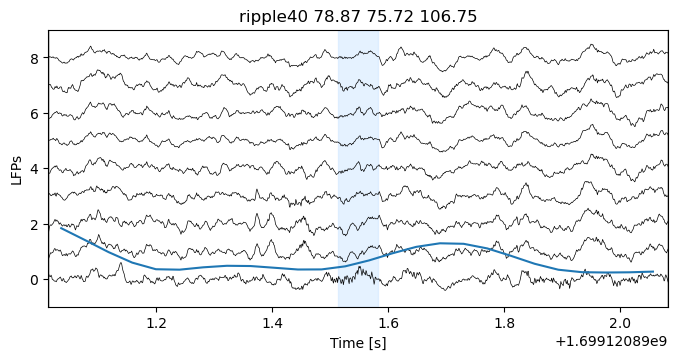

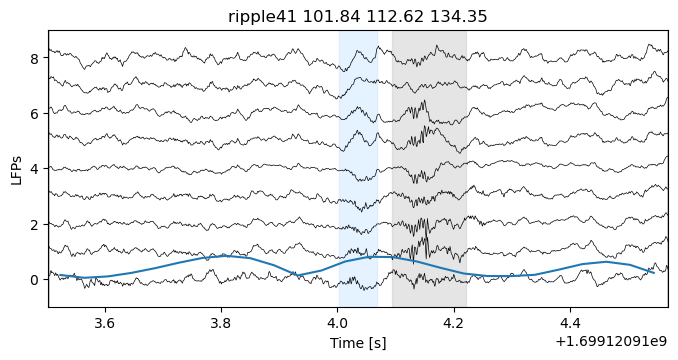

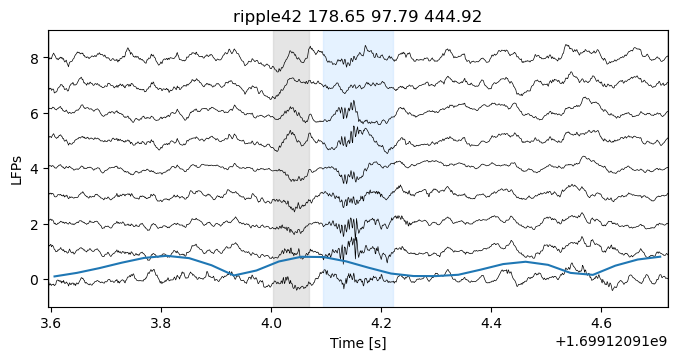

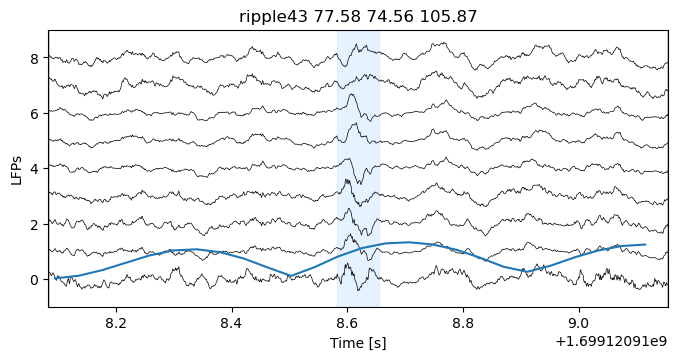

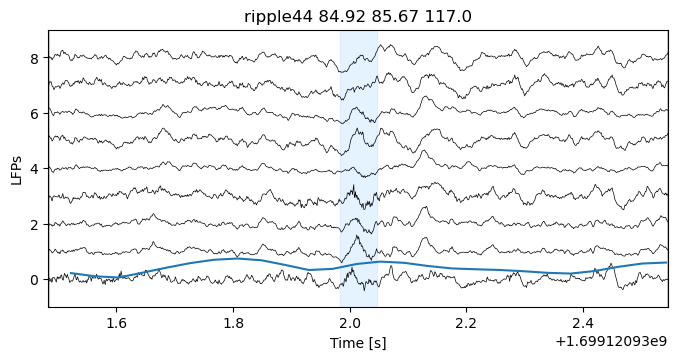

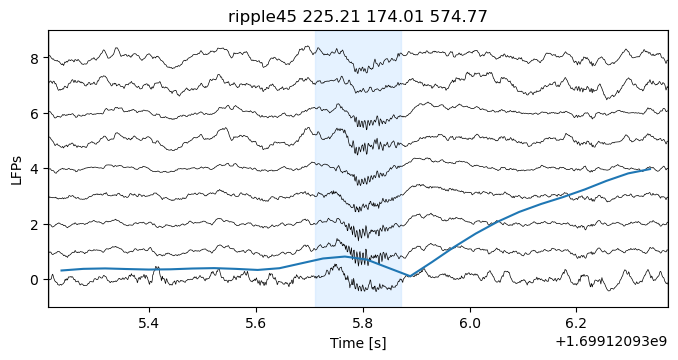

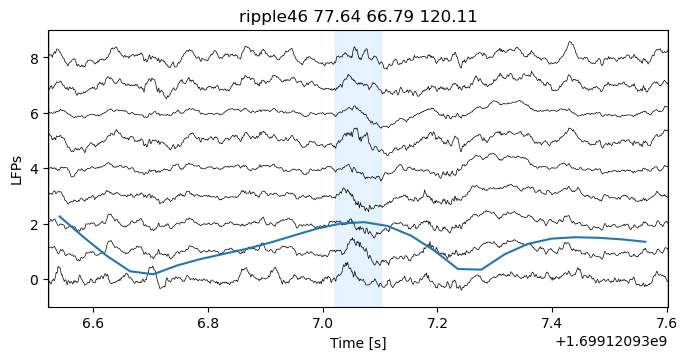

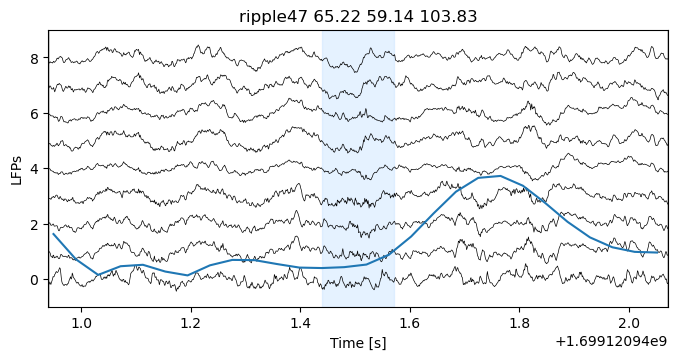

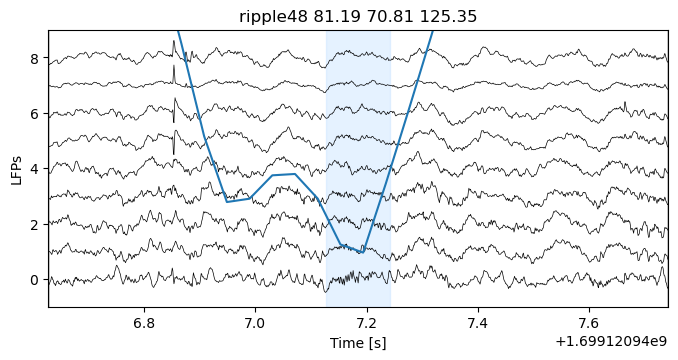

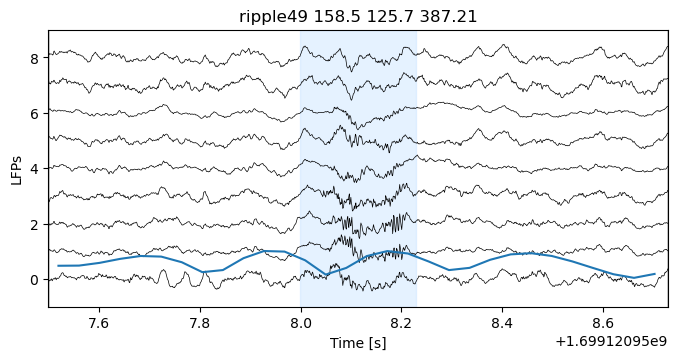

In [267]:
"""plot ripple events"""
offset = 0.5
for r in test.index[40:50]:
    #ripple_name = RippleTimes_Karlsson_processed[animal].iloc[r].name
    _,ax = plot_ripple(lfp_df, test,
                ripple_label=r,  offset=offset, relative=False)
    # two cc channel data are in the top 2 rows.

    # Add speed into on top
    op = test.loc[r].start_time - offset
    ed = test.loc[r].end_time + offset
    ind = np.logical_and(position_info.index >= op, position_info.index <= ed)
    
    plt.plot(position_info.head_speed[ind])

    ax.set_title('ripple'+str(r)+' '+str(round(test.loc[r].mean_zscore,2)) + ' ' +
                 str(round(test.loc[r].median_zscore,2)) + ' ' +str(round(test.loc[r].max_zscore,2)))



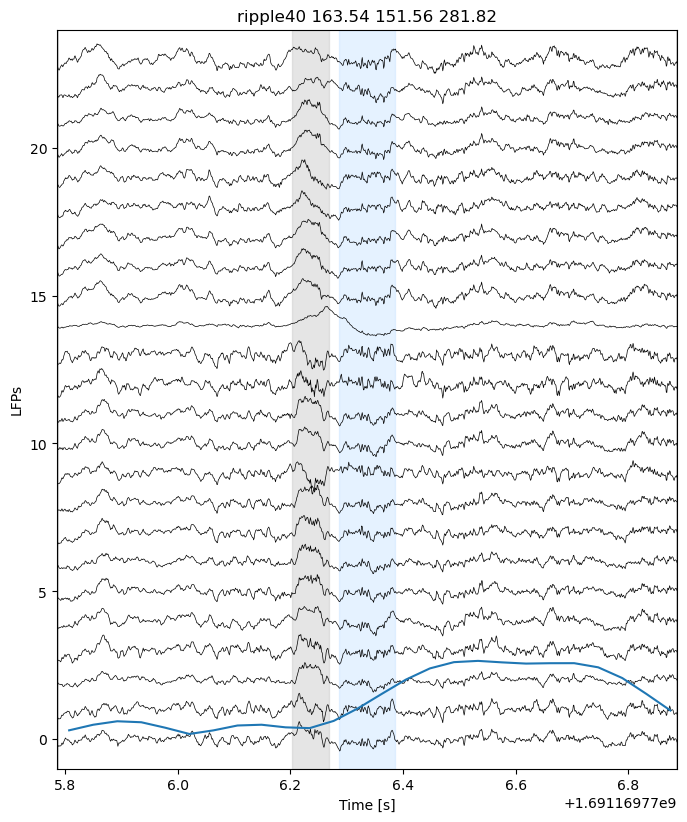

In [26]:
"""plot ripple events"""
offset = 0.5
for r in [40]:
    #ripple_name = RippleTimes_Karlsson_processed[animal].iloc[r].name
    _,ax = plot_ripple(lfp_df, test,
                ripple_label=r,  offset=offset, relative=False)

    # Add speed into on top
    op = test.loc[r].start_time - offset
    ed = test.loc[r].end_time + offset
    ind = np.logical_and(position_info.index >= op, position_info.index <= ed)
    
    plt.plot(position_info.head_speed[ind])

    ax.set_title('ripple'+str(r)+' '+str(round(test.loc[r].mean_zscore,2)) + ' ' +
                 str(round(test.loc[r].median_zscore,2)) + ' ' +str(round(test.loc[r].max_zscore,2)))

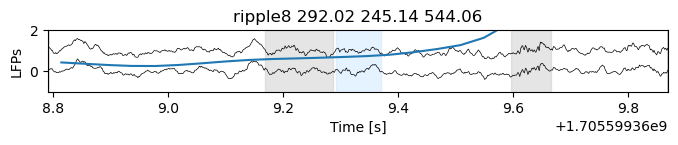

In [674]:
"""plot ripple events"""
offset = 0.5
for r in [8]:
    #ripple_name = RippleTimes_Karlsson_processed[animal].iloc[r].name
    _,ax = plot_ripple(lfp_df_cc, test,
                ripple_label=r,  offset=offset, relative=False)

    # Add speed into on top
    op = test.loc[r].start_time - offset
    ed = test.loc[r].end_time + offset
    ind = np.logical_and(position_info.index >= op, position_info.index <= ed)
    
    plt.plot(position_info.head_speed[ind])

    ax.set_title('ripple'+str(r)+' '+str(round(test.loc[r].mean_zscore,2)) + ' ' +
                 str(round(test.loc[r].median_zscore,2)) + ' ' +str(round(test.loc[r].max_zscore,2)))

### 3. Run all sessions.

In [15]:
from spyglass.shijiegu.load import load_session_name

In [17]:
session_interval, sleep_interval = load_session_name(nwb_copy_file_name)
run_sessionIDs = [int(session[:2]) for session in session_interval]
print(run_sessionIDs)

[2, 4, 6, 8, 10, 12]


In [18]:
epochs_to_run = run_sessionIDs #epochs#[1:] #if not running the first session

In [19]:
#(RippleTimes & {'nwb_file_name': nwb_copy_file_name}).delete()

In [20]:
epochs_to_run

[2, 4, 6, 8, 10, 12]

In [23]:
for e in epochs_to_run:
    ripple_times, CA1TetrodeInd, CCTetrodeInd = ripple_detection_master(
        nwb_file_name,e,conservative = False,fieldname = 'artifact removed')
    epoch_name = (EpochPos() & {'nwb_file_name': nwb_copy_file_name ,'epoch':e}).fetch1('epoch_name')

    animal = nwb_copy_file_name[:5]
    savePath=os.path.join(f'/cumulus/shijie/recording_pilot/{animal}/decoding',
                        nwb_copy_file_name+'_'+epoch_name+'_ripple_times.nc')
    ripple_times.to_csv(savePath)

    # for the RippleTimes table
    key = {'nwb_file_name': nwb_copy_file_name, 'interval_list_name': epoch_name}
    key['ripple_times'] = savePath
    RippleTimes().insert1(key,replace = True)

    # for the TetrodeNumber table
    key = {'nwb_file_name': nwb_copy_file_name, 'epoch':e, 'epoch_name': epoch_name}
    key['ca1_tetrode_ind'] = CA1TetrodeInd
    key['cc_tetrode_ind'] = CCTetrodeInd
    TetrodeNumber().insert1(key,replace = True)
    
# to get data out:
# test = (RippleTimes() & {'nwb_file_name': nwb_copy_file_name, 'interval_list_name': epoch_name}).fetch1('ripple_times')
# len(pd.DataFrame(test))

Using LFP from these eletrodes: 
[ 2  3  6  7  8 11 12 15 17 20 22 26 27 28 29 30 31 42 49 51 55 56 61]




[2026-03-15 14:02:22,965][WARNING]: Skipped checksum for file with hash: 31189be1-3792-876a-3a4e-181c2ab9a671, and path: /stelmo/nwb/analysis/julio20230731/julio20230731_HW8DK54Y1W.nwb
[2026-03-15 14:02:32,505][WARNING]: Skipped checksum for file with hash: a8a4d9d6-cbc6-53e1-929a-b57eb5c0dd11, and path: /stelmo/nwb/analysis/julio20230731/julio20230731_SA6HTTELZ6.nwb
[2026-03-15 14:02:32,517][WARNING]: Skipped checksum for file with hash: a8a4d9d6-cbc6-53e1-929a-b57eb5c0dd11, and path: /stelmo/nwb/analysis/julio20230731/julio20230731_SA6HTTELZ6.nwb
[2026-03-15 14:02:32,528][WARNING]: Skipped checksum for file with hash: a8a4d9d6-cbc6-53e1-929a-b57eb5c0dd11, and path: /stelmo/nwb/analysis/julio20230731/julio20230731_SA6HTTELZ6.nwb
[2026-03-15 14:02:32,536][WARNING]: Skipped checksum for file with hash: a8a4d9d6-cbc6-53e1-929a-b57eb5c0dd11, and path: /stelmo/nwb/analysis/julio20230731/julio20230731_SA6HTTELZ6.nwb


The shape of LFP input is (2313722, 19)


/home/shijiegu/anaconda3/envs/spyglass/lib/python3.10/site-packages/ripple_detection/core.py:47: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  is_start_time = (~series.shift(1).fillna(False)) & series
/home/shijiegu/anaconda3/envs/spyglass/lib/python3.10/site-packages/ripple_detection/core.py:50: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  is_end_time = series & (~series.shift(-1).fillna(False))


consensus only
Found 438 events.
Using LFP from these eletrodes: 
[ 2  3  6  7  8 11 12 15 17 20 22 26 27 28 29 30 31 42 49 51 55 56 61]




...

consensus only
Found 623 events.
Using LFP from these eletrodes: 
[ 2  3  6  7  8 11 12 15 17 20 22 26 27 28 29 30 31 42 49 51 55 56 61]




[2026-03-15 14:06:53,385][WARNING]: Skipped checksum for file with hash: 5ee5d276-9450-573c-5393-649337e82e1f, and path: /stelmo/nwb/analysis/julio20230731/julio20230731_BF83X4V68U.nwb
[2026-03-15 14:07:02,753][WARNING]: Skipped checksum for file with hash: 858b2305-41fc-e306-a1f0-29515990603e, and path: /stelmo/nwb/analysis/julio20230731/julio20230731_D4510ZI0PW.nwb
[2026-03-15 14:07:02,763][WARNING]: Skipped checksum for file with hash: 858b2305-41fc-e306-a1f0-29515990603e, and path: /stelmo/nwb/analysis/julio20230731/julio20230731_D4510ZI0PW.nwb
[2026-03-15 14:07:02,773][WARNING]: Skipped checksum for file with hash: 858b2305-41fc-e306-a1f0-29515990603e, and path: /stelmo/nwb/analysis/julio20230731/julio20230731_D4510ZI0PW.nwb
[2026-03-15 14:07:02,780][WARNING]: Skipped checksum for file with hash: 858b2305-41fc-e306-a1f0-29515990603e, and path: /stelmo/nwb/analysis/julio20230731/julio20230731_D4510ZI0PW.nwb


The shape of LFP input is (2707143, 19)


/home/shijiegu/anaconda3/envs/spyglass/lib/python3.10/site-packages/ripple_detection/core.py:47: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  is_start_time = (~series.shift(1).fillna(False)) & series
/home/shijiegu/anaconda3/envs/spyglass/lib/python3.10/site-packages/ripple_detection/core.py:50: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  is_end_time = series & (~series.shift(-1).fillna(False))


consensus only
Found 705 events.


In [22]:
%debug

> /home/shijiegu/anaconda3/envs/spyglass/lib/python3.10/site-packages/hdmf/utils.py(1031)__getitem__()
   1029                 return super().__getitem__(val)
   1030         else:
-> 1031             return super().__getitem__(key)
   1032 
   1033     def __setitem__(self, key, value):



ipdb>  u


> /home/shijiegu/Documents/spyglass/src/spyglass/shijiegu/ripple_detection.py(277)loadRippleLFP()
    275         ripple_nwb = io.read()
    276 
--> 277         filtered_t=np.array(ripple_nwb.scratch[fieldname].timestamps)
    278         electrodes=ripple_nwb.scratch[fieldname].electrodes.to_dataframe()
    279         # TO DO: return directly the electrode IDs. Now it is just a nwb file which I do not know how to get IDs from



ipdb>  ripple_nwb.scratch


{'artifact removed': artifact removed pynwb.ecephys.ElectricalSeries at 0x140229827217296
Fields:
  comments: no comments
  conversion: 1.0
  description: no description
  interval: 1
  offset: 0.0
  resolution: -1.0
  timestamps_unit: seconds
  unit: volts
, 'filtered data': filtered data pynwb.ecephys.ElectricalSeries at 0x140229827220656
Fields:
  comments: no comments
  conversion: 1.0
  description: no description
  interval: 1
  offset: 0.0
  resolution: -1.0
  timestamps_unit: seconds
  unit: volts
}


ipdb>  exit


In [116]:
(RippleTimes & {'nwb_file_name': nwb_copy_file_name})#.delete()

nwb_file_name name of the NWB file,interval_list_name descriptive name of this interval list,ripple_times ripple times within that interval,ripple_times_04sd ripple times within that interval,ripple_times_1sd ripple times within that interval,ripple_times_2sd ripple times within that interval
klein20231112_.nwb,02_Rev2Session1,=BLOB=,=BLOB=,=BLOB=,=BLOB=
klein20231112_.nwb,04_Rev2Session2,=BLOB=,=BLOB=,=BLOB=,=BLOB=
klein20231112_.nwb,06_Rev2Session3,=BLOB=,=BLOB=,=BLOB=,=BLOB=
klein20231112_.nwb,08_Rev2Session4,=BLOB=,=BLOB=,=BLOB=,=BLOB=


In [24]:
(TetrodeNumber() & {'nwb_file_name': nwb_copy_file_name})

nwb_file_name name of the NWB file,epoch the session epoch for this task and apparatus(1 based),"epoch_name session name, get from IntervalList",ca1_tetrode_ind 0-based indices of CA1 tetrodes channels. These can be used for plotting,cc_tetrode_ind 0-based indices of Corpus Collosum tetrodes channels. These can be used for plotting
julio20230731_.nwb,2,02_Seq2Session1,=BLOB=,=BLOB=
julio20230731_.nwb,4,04_Seq2Session2,=BLOB=,=BLOB=
julio20230731_.nwb,6,06_Seq2Session3,=BLOB=,=BLOB=
julio20230731_.nwb,8,08_Seq2Session4,=BLOB=,=BLOB=
julio20230731_.nwb,10,10_Seq2Session5,=BLOB=,=BLOB=
julio20230731_.nwb,12,12_Seq2Session6,=BLOB=,=BLOB=


# End here

## Below are just code to inspect add decode

In [92]:
nwb_file_name = 'eliot20221021.nwb'
nwb_copy_file_name=get_nwb_copy_filename(nwb_file_name)

In [110]:
from spyglass.shijiegu.load import load_position

In [112]:
epochID = 2

# find epoch/session name and position interval name
key = (EpochPos & {'nwb_file_name':nwb_copy_file_name,'epoch':epochID}).fetch1()
epoch_name = key['epoch_name']
position_interval = key['position_interval']

position_valid_times = (IntervalList & {'nwb_file_name': nwb_copy_file_name,
                                            'interval_list_name': position_interval}).fetch1('valid_times')

# Ripple Band LFP
filtered_lfps, filtered_lfps_t, CA1TetrodeInd, CCTetrodeInd = loadRippleLFP_OneChannelPerElectrode(
    nwb_copy_file_name,epoch_name,position_valid_times)

Using LFP from these eletrodes: 
[ 0  2  4  5 13 14 16 17 20 23 26 27 28 29 30 31]




In [118]:
(TrialChoice & {'nwb_file_name':nwb_copy_file_name,'epoch':int(epoch_name[:2])})

nwb_file_name name of the NWB file,epoch the session epoch for this task and apparatus(1 based),"epoch_name session name, get from IntervalList","choice_reward pandas dataframe, choice"
eliot20221022_.nwb,2,02_Seq2Session1,=BLOB=


In [120]:
neural_data,neural_ts,mua_time,mua,channel_IDs = load_spike(nwb_copy_file_name,
                                                            epoch_name,tetrode_list=[100,101])



NameError: name 'interval_list_name' is not defined

In [121]:
# Remove Data before 1st trial and after last trial
StateScript = pd.DataFrame(
    (TrialChoice & {'nwb_file_name':nwb_copy_file_name,
                        'epoch_name':epoch_name}).fetch1('choice_reward')
)

trial_1_t = StateScript.loc[1].timestamp_O
trial_last_t = StateScript.loc[len(StateScript)-1].timestamp_O

In [113]:
position_info = load_position(nwb_copy_file_name,position_interval)
position_info_upsample = interpolate_to_new_time(position_info, filtered_lfps_t)

# Remove Data before 1st trial and after last trial
StateScript = pd.DataFrame(
        (TrialChoice & {'nwb_file_name':nwb_copy_file_name,'epoch':int(epoch_name[:2])}).fetch1('choice_reward')
)

trial_1_t = StateScript.loc[1].timestamp_O
trial_last_t = StateScript.loc[len(StateScript)-1].timestamp_O
position_info_upsample = removeDataBeforeTrial1(position_info_upsample,trial_1_t,trial_last_t)
position_info_upsample = removeArtifactTime(position_info_upsample, filtered_lfps)

In [115]:
#position_info_upsample

In [94]:
epochs = (TaskEpoch & {'nwb_file_name': nwb_copy_file_name}).fetch('epoch')
for e in epochs:
    EpochPos().make({'nwb_file_name': nwb_copy_file_name,'epoch':e},replace = True)
EpochPos() & {'nwb_file_name': nwb_copy_file_name}

nwb_file_name name of the NWB file,epoch the session epoch for this task and apparatus(1 based),epoch_name TaskEpoch or IntervalList,position_interval IntervalPositionInfo
eliot20221021_.nwb,1,01_Seq2Sleep1,pos 0 valid times
eliot20221021_.nwb,2,02_Seq2Session1,pos 1 valid times
eliot20221021_.nwb,3,03_Seq2Sleep2,pos 2 valid times
eliot20221021_.nwb,4,04_Seq2Session2,pos 3 valid times
eliot20221021_.nwb,5,05_Seq2Sleep3,pos 4 valid times
eliot20221021_.nwb,6,06_Seq2Session3,pos 5 valid times
eliot20221021_.nwb,7,07_Seq2Sleep4,pos 6 valid times
eliot20221021_.nwb,8,08_Seq2Session4,pos 7 valid times
eliot20221021_.nwb,9,09_Seq2Sleep5,pos 8 valid times


In [95]:
key = (EpochPos & {'nwb_file_name':nwb_copy_file_name,'epoch':epochID}).fetch1()
epoch_name = key['epoch_name']
position_interval = key['position_interval']
print(epoch_name)

test = pd.DataFrame((RippleTimes() & {'nwb_file_name': nwb_copy_file_name,
                                              'interval_list_name': epoch_name}).fetch1('ripple_times'))

02_Seq2Session1


In [96]:
test

,start_time,end_time,animal_location,trial_number,cont_intvl,frag_intvl,cont_intvl_replay,duration,mean_zscore,median_zscore,max_zscore,min_zscore,speed_at_start,speed_at_end,max_speed,min_speed,median_speed,mean_speed
1,1.666383e+09,1.666383e+09,home,2,"[[1666383001.639959, 1666383001.6919594]]","[[1666383001.7139592, 1666383001.7559593]]",[[2]],0.170,1.762955,1.717227,3.987851,-0.124566,0.568382,0.064261,0.568382,0.064261,0.255306,0.275427
2,1.666383e+09,1.666383e+09,home,3,"[[1666383044.7179408, 1666383044.7539408]]","[[1666383044.7579408, 1666383044.9019406]]",[[1]],0.208,2.903275,2.305399,7.846824,-0.436577,0.173547,0.173547,0.173548,0.173547,0.173547,0.173547
3,1.666383e+09,1.666383e+09,home,3,"[[1666383046.16594, 1666383046.2199402]]","[[1666383046.2259402, 1666383046.24794]]",[[0]],0.089,1.197001,0.647694,4.383852,-0.282330,0.173547,0.173549,0.173549,0.173547,0.173548,0.173548
4,1.666383e+09,1.666383e+09,well3,3,"[[1666383061.7079334, 1666383061.751933]]","[[1666383061.5819335, 1666383061.7019334]]",[[2]],0.173,1.698708,1.534566,3.814605,-0.594820,0.050467,0.050467,0.050467,0.050467,0.050467,0.050467
5,1.666383e+09,1.666383e+09,home,4,"[[1666383077.9039264, 1666383077.9479263], [16...","[[1666383078.0499263, 1666383078.0699265]]","[[2], [2]]",0.251,1.706619,1.042135,7.538818,-0.689623,0.604633,0.604633,0.604635,0.604633,0.604634,0.604634
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
127,1.666385e+09,1.666385e+09,home,77,"[[1666385089.315059, 1666385089.341059], [1666...","[[1666385089.3450592, 1666385089.369059], [166...","[[2], [1]]",0.220,4.817131,3.076295,17.889181,-0.933976,0.191644,0.191644,0.191644,0.191644,0.191644,0.191644
128,1.666385e+09,1.666385e+09,home,78,"[[1666385109.2570505, 1666385109.3230505]]",[],[[2]],0.106,1.621713,1.530860,3.736403,-0.494129,0.681662,0.681666,0.681666,0.681662,0.681664,0.681664
129,1.666385e+09,1.666385e+09,home,78,"[[1666385112.2070491, 1666385112.2610493]]","[[1666385112.2690492, 1666385112.373049]]",[[4]],0.200,6.084937,2.086158,28.721109,-0.676374,0.681654,0.681666,0.681666,0.681654,0.681663,0.681662
130,1.666385e+09,1.666385e+09,home,80,"[[1666385158.6990292, 1666385158.7550292], [16...",[],"[[0], [0]]",0.139,1.633406,1.571654,3.498120,0.005398,0.407345,0.407346,0.407346,0.407345,0.407346,0.407346


In [44]:
"""Get broad band LFP"""
lfp,lfp_t = load_LFP(nwb_copy_file_name,epoch_name)

lfp_df = pd.DataFrame(data=lfp[:,CA1TetrodeInd], index=lfp_t)
lfp_df.index.name='time'
lfp_df=xr.Dataset.from_dataframe(lfp_df)

[2024-06-19 10:59:21,366][WARNING]: Skipped checksum for file with hash: 65756212-f56e-fc3c-339a-369742efcaf5, and path: /stelmo/nwb/analysis/eliot20221021/eliot20221021_O0JEUX5SSA.nwb


In [45]:
"""Load Position Info"""
position_info = load_position(nwb_copy_file_name,position_interval)
#position_info_upsample = interpolate_to_new_time(position_info, lfp_t)

In [97]:
test.loc[5]

start_time                                           1666383077.898365
end_time                                             1666383078.149366
animal_location                                                   home
trial_number                                                         4
cont_intvl           [[1666383077.9039264, 1666383077.9479263], [16...
frag_intvl                  [[1666383078.0499263, 1666383078.0699265]]
cont_intvl_replay                                           [[2], [2]]
duration                                                         0.251
mean_zscore                                                   1.706619
median_zscore                                                 1.042135
max_zscore                                                    7.538818
min_zscore                                                   -0.689623
speed_at_start                                                0.604633
speed_at_end                                                  0.604633
max_sp

In [99]:
test.loc[5].cont_intvl

array([[1.66638308e+09, 1.66638308e+09],
       [1.66638308e+09, 1.66638308e+09]])

In [54]:
from spyglass.shijiegu.load import load_decode 
decode=load_decode(nwb_copy_file_name,epoch_name)

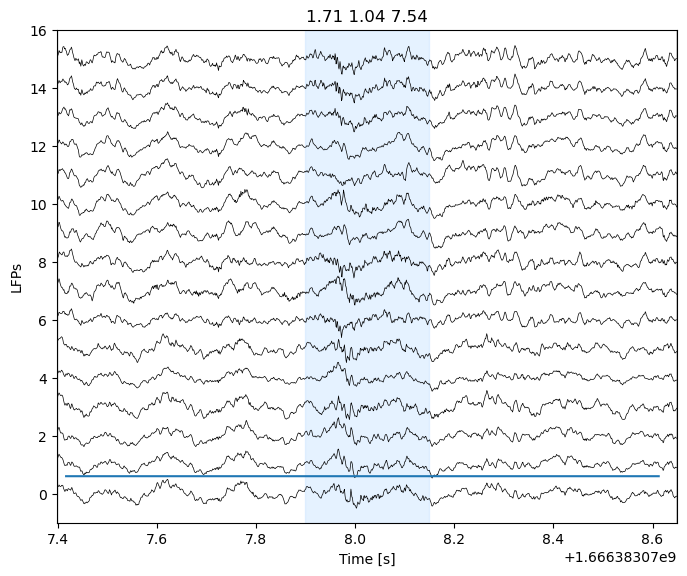

In [46]:
"""plot ripple events"""
offset = 0.5
for r in [test.index[4]]:
    #ripple_name = RippleTimes_Karlsson_processed[animal].iloc[r].name
    _,ax = plot_ripple(lfp_df, test,
                ripple_label=r,  offset=offset, relative=False)

    # Add speed into on top
    op = test.loc[r].start_time - offset
    ed = test.loc[r].end_time + offset
    ind = np.logical_and(position_info.index >= op, position_info.index <= ed)
    
    plt.plot(position_info.head_speed[ind])

    ax.set_title(str(round(test.loc[r].mean_zscore,2)) + ' ' +
                 str(round(test.loc[r].median_zscore,2)) + ' ' +str(round(test.loc[r].max_zscore,2)))

